## **Aula de Econometria e Otimização**

Este notebook explora a **Otimização Linear e Precificação no Varejo**. Ele aborda as seguintes etapas principais:

1.  **Configuração e Carregamento de Dados**: Inicializa o ambiente e carrega o conjunto de dados `retail_price.csv`.
2.  **EDA e Engenharia de Features**: Cria novas métricas de precificação e concorrência, aplica transformações logarítmicas e define um custo unitário hipotético para calcular as margens. Inclui também análise exploratória de dados para entender as relações preço-volume.
3.  **Modelagem Econométrica**: Estima a elasticidade-preço da demanda usando modelos de regressão log-log simples e controlados.
4.  **Programação Linear (LP)**: Resolve um problema clássico de alocação de capacidade usando `scipy.optimize.linprog`.
5.  **Programação Linear Inteira Mista (MILP) para Precificação**: Desenvolve um modelo MILP baseado em cenários para otimizar a precificação em múltiplos SKUs, considerando a elasticidade da demanda e as restrições operacionais.
6.  **Análise de Sensibilidade e Robustez**: Testa a estabilidade das recomendações de precificação sob diferentes cenários de demanda macroeconômica.

In [3]:
# ==============================================================================
# GOOGLE COLAB / JUPYTER NOTEBOOK: OTIMIZAÇÃO LINEAR & PRICING NO VAREJO
# Dataset Base: retail_price.csv (676 linhas, 30 colunas)
# ==============================================================================
# PIPELINE DA AULA:
# 1. Setup & Carga do Dataset retail_price.csv
# 2. EDA & Feature Engineering com as 30 colunas reais
# 3. Modelagem Econométrica: Elasticidade Log-Log Simples vs. Controlada (-2.41)
# 4. Programação Linear (LP) com scipy.optimize.linprog
# 5. Programação Linear Inteira Mista (MILP) com scipy.optimize.milp
# 6. Pipeline Ponta a Ponta: Previsão de Demanda -> MILP de Cenários por SKU
# 7. Análise de Sensibilidade & Robustez
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. SETUP DE AMBIENTE E CARGA DO DATASET
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from scipy.optimize import linprog, milp, LinearConstraint, Bounds
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Leitura do arquivo anexo
CSV_PATH = "/content/retail_price.csv"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Certifique-se de que '{CSV_PATH}' está no diretório de execução.")

df = pd.read_csv(CSV_PATH)

print("="*70)
print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape[0]} linhas e {df.shape[1]} colunas")
print("Colunas presentes:")
print(list(df.columns))
print("="*70)

display(df.head(3))

Dataset carregado com sucesso!
Dimensões: 676 linhas e 30 colunas
Colunas presentes:
['product_id', 'product_category_name', 'month_year', 'qty', 'total_price', 'freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price']


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.0,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.0,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.0,4.4,22.195932,45.95,4.0,14.840000,45.95


### 1. Configuração e Carregamento do Conjunto de Dados

Esta célula realiza a configuração inicial do notebook. Ela importa as bibliotecas necessárias, como `pandas` para manipulação de dados, `numpy` para operações numéricas, `matplotlib` e `seaborn` para plotagem, e `statsmodels` e `sklearn` para modelagem estatística e aprendizado de máquina. Ela também define parâmetros globais de plotagem para melhor visualização.

Em seguida, define o caminho para o conjunto de dados `retail_price.csv`, verifica se o arquivo existe e o carrega em um DataFrame pandas chamado `df`. Por fim, imprime as dimensões e os nomes das colunas do conjunto de dados carregado e exibe as 3 primeiras linhas para fornecer uma visão geral rápida dos dados.

#### Feature Engineering

--- Resumo Agregado por Categoria ---


,produtos,observacoes,volume_total,receita_total,preco_medio,indice_preco_medio
product_category_name,,,,,,
health_beauty,10,130,1842,212419.409166,132.309870,2.182157
watches_gifts,8,103,1431,207555.077304,164.880007,1.128432
garden_tools,10,160,2398,163426.743096,80.094699,1.392844
computers_accessories,6,69,1167,141928.387792,119.482323,0.927256
bed_bath_table,5,61,1026,95080.497304,78.629278,1.008068
cool_stuff,5,57,558,57956.300001,107.857512,1.065975
furniture_decor,4,48,894,56942.267049,60.154262,0.895594
perfumery,2,26,244,20312.511111,89.348813,0.970645
consoles_games,2,22,239,5799.833333,27.033766,0.999988


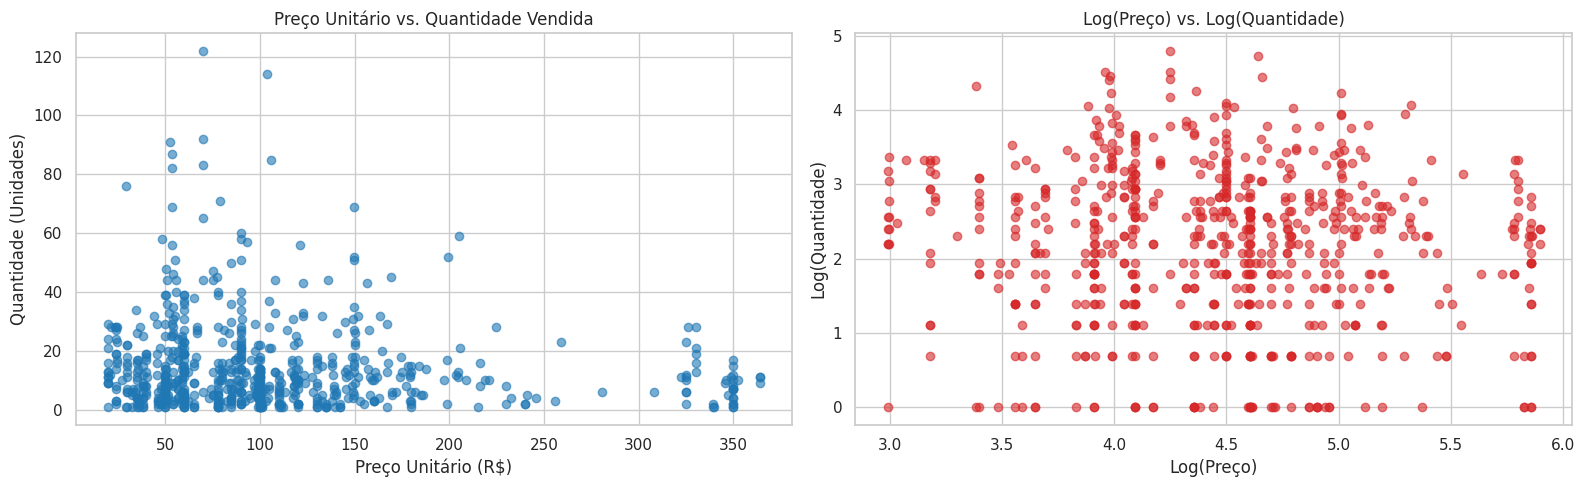

Correlação linear de Pearson entre unit_price e qty: -0.1034


In [5]:
# 2.1 Métricas de Preço e Concorrência
df["revenue"] = df["qty"] * df["unit_price"]

# Preço médio e mínimo dos concorrentes 1, 2 e 3
df["avg_comp_price"] = df[["comp_1", "comp_2", "comp_3"]].mean(axis=1)
df["min_comp_price"] = df[["comp_1", "comp_2", "comp_3"]].min(axis=1)

# Indicadores de posicionamento competitivo
df["price_index"] = df["unit_price"] / df["avg_comp_price"]
df["comp_gap_pct"] = (df["unit_price"] / df["avg_comp_price"]) - 1.0
df["price_change_pct"] = (df["unit_price"] / df["lag_price"]) - 1.0

# 2.2 Transformações Logarítmicas
df["log_price"] = np.log(df["unit_price"])
df["log_qty"] = np.log(df["qty"])
df["log_comp_price"] = np.log(df["avg_comp_price"])

# 2.3 Custo Unitário Hipotético (Proxy didático: 60% do preço observado como CMV)
df["unit_cost"] = df["unit_price"] * 0.60
df["unit_margin"] = df["unit_price"] - df["unit_cost"]
df["total_margin"] = df["qty"] * df["unit_margin"]

print("--- Resumo Agregado por Categoria ---")
category_summary = (
    df.groupby("product_category_name")
      .agg(
          produtos=("product_id", "nunique"),
          observacoes=("product_id", "size"),
          volume_total=("qty", "sum"),
          receita_total=("revenue", "sum"),
          preco_medio=("unit_price", "mean"),
          indice_preco_medio=("price_index", "mean")
      )
      .sort_values("receita_total", ascending=False)
)
display(category_summary)

# Visualização da dispersão de preço vs volume
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(df["unit_price"], df["qty"], color='#1f77b4', alpha=0.6)
axes[0].set_title("Preço Unitário vs. Quantidade Vendida")
axes[0].set_xlabel("Preço Unitário (R$)")
axes[0].set_ylabel("Quantidade (Unidades)")

axes[1].scatter(df["log_price"], df["log_qty"], color='#d62728', alpha=0.6)
axes[1].set_title("Log(Preço) vs. Log(Quantidade)")
axes[1].set_xlabel("Log(Preço)")
axes[1].set_ylabel("Log(Quantidade)")

plt.tight_layout()
plt.show()

corr_linear = df[["unit_price", "qty"]].corr().iloc[0, 1]
print(f"Correlação linear de Pearson entre unit_price e qty: {corr_linear:.4f}")

### 2. Engenharia de Features e Análise Exploratória de Dados (EDA)

Esta seção foca na criação de novas features relevantes para a análise de precificação e na condução de análises exploratórias de dados.

-   **2.1 Métricas de Preço e Concorrência**: Calcula `revenue` (receita), `avg_comp_price` (preço médio do concorrente), `min_comp_price` (preço mínimo do concorrente), `price_index` (nosso preço em relação ao preço médio do concorrente), `comp_gap_pct` (diferença percentual em relação ao preço médio do concorrente) e `price_change_pct` (mudança de preço em relação ao mês anterior).
-   **2.2 Transformações Logarítmicas**: Aplica a transformação de logaritmo natural a `unit_price`, `qty` e `avg_comp_price`. Essas variáveis transformadas em log são frequentemente usadas em modelos econométricos para estimar elasticidades diretamente.
-   **2.3 Custo Unitário Hipotético**: Introduz um proxy didático para o custo unitário e a margem, assumindo que o custo unitário é 60% do preço unitário.

A célula então resume as principais métricas agregadas por categoria de produto, fornecendo insights sobre volume de vendas, receita, preço médio e índice de preço por categoria. Por fim, visualiza a relação entre `unit_price` e `qty` (ambos em escalas originais e transformadas em log) usando gráficos de dispersão e calcula o coeficiente de correlação de Pearson para quantificar sua relação linear.

#### Estimativa Econométrica de elasticidade de preço

### 3. Estimativa Econométrica da Elasticidade-Preço da Demanda

Esta seção estima a elasticidade-preço da demanda usando dois modelos econométricos:

-   **Modelo 1 (Ingênuo)**: Uma regressão log-log simples onde `log_qty` é regredido contra `log_price`. Isso fornece uma estimativa básica da elasticidade-preço sem controlar por outros fatores.

    A fórmula é: `ln(qty) = alpha + beta * ln(unit_price)`

-   **Modelo 2 (Controlado)**: Uma regressão log-log mais sofisticada que inclui variáveis de controle e efeitos fixos para isolar o verdadeiro impacto das mudanças de preço na demanda. Este modelo considera os preços dos concorrentes, frete, pontuação do produto, dia da semana (fim de semana), efeitos de feriado e efeitos fixos para `product_id` e `month`.

    A fórmula é: `ln(qty) = alpha + beta*ln(unit_price) + gamma*ln(avg_comp_price) + delta*freight_price + theta*product_score + lambda*weekend + phi*holiday + EfeitoFixo(product_id) + EfeitoFixo(month)`

A célula imprime o resumo de ambos os modelos, destacando suas elasticidades estimadas (`beta`) e valores de R-quadrado, que indicam o poder explicativo dos modelos. Ela também calcula e exibe as estimativas de elasticidade para cada categoria de produto individualmente, usando o modelo ingênuo.

In [6]:
# ------------------------------------------------------------------------------
# 3. ESTIMATIVA ECONOMÉTRICA DA ELASTICIDADE-PREÇO DA DEMANDA
# ------------------------------------------------------------------------------
"""
Modelo 1 (Ingênuo):
ln(qty) = alpha + beta * ln(unit_price)

Modelo 2 (Controlado com Efeitos Fixos e Variáveis do Dataset):
ln(qty) = alpha + beta*ln(unit_price) + gamma*ln(avg_comp_price) + delta*freight_price
          + theta*product_score + lambda*weekend + phi*holiday
          + EfeitoFixo(product_id) + EfeitoFixo(month)
"""

# Modelo 1: Log-Log Simples
model_naive = smf.ols("log_qty ~ log_price", data=df).fit()

print("="*75)
print("MODELO 1: REGRESSÃO LOG-LOG UNIVARIADA (INGÊNUA)")
print("="*75)
print(model_naive.summary().tables[1])
beta_naive = model_naive.params["log_price"]
print(f"\n-> Elasticidade Estimada Ingênua (beta): {beta_naive:.4f} (R²: {model_naive.rsquared:.4f})")

# Modelo 2: Log-Log com Controles Reais do Dataset
model_controlled = smf.ols("""
    log_qty ~ log_price
    + log_comp_price
    + freight_price
    + product_score
    + weekend
    + holiday
    + C(product_id)
    + C(month)
""", data=df).fit()

print("\n" + "="*75)
print("MODELO 2: REGRESSÃO LOG-LOG COM CONTROLES E EFEITOS FIXOS")
print("="*75)
beta_ctrl = model_controlled.params["log_price"]
p_val_ctrl = model_controlled.pvalues["log_price"]
print(f"-> Elasticidade Estimada Controlada (beta): {beta_ctrl:.4f}")
print(f"-> p-valor: {p_val_ctrl:.4e} | R² Ajustado: {model_controlled.rsquared_adj:.4f}")

# Elasticidade por categoria
cat_results = []
for cat, grp in df.groupby("product_category_name"):
    if len(grp) >= 10:
        res = smf.ols("log_qty ~ log_price", data=grp).fit()
        cat_results.append({
            "Categoria": cat,
            "N_Obs": len(grp),
            "Elasticidade (beta)": res.params.get("log_price", np.nan),
            "p-valor": res.pvalues.get("log_price", np.nan),
            "R²": res.rsquared
        })

df_cat_elast = pd.DataFrame(cat_results).sort_values("Elasticidade (beta)")
print("\n--- Elasticidade Log-Log Estimada por Categoria ---")
display(df_cat_elast)

MODELO 1: REGRESSÃO LOG-LOG UNIVARIADA (INGÊNUA)
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.7681      0.281      9.862      0.000       2.217       3.319
log_price     -0.1313      0.062     -2.107      0.036      -0.254      -0.009

-> Elasticidade Estimada Ingênua (beta): -0.1313 (R²: 0.0065)

MODELO 2: REGRESSÃO LOG-LOG COM CONTROLES E EFEITOS FIXOS
-> Elasticidade Estimada Controlada (beta): -2.4119
-> p-valor: 2.0340e-10 | R² Ajustado: 0.2289

--- Elasticidade Log-Log Estimada por Categoria ---


,Categoria,N_Obs,Elasticidade (beta),p-valor,R²
2,consoles_games,22,-2.275908,0.012395,0.274118
5,garden_tools,160,-0.798510,0.000169,0.085897
7,perfumery,26,-0.579849,0.172494,0.076115
8,watches_gifts,103,-0.315897,0.217388,0.015025
6,health_beauty,130,-0.144127,0.087363,0.022659
3,cool_stuff,57,0.136903,0.691564,0.002884
4,furniture_decor,48,0.308026,0.456028,0.012136
1,computers_accessories,69,0.398038,0.443906,0.008775
0,bed_bath_table,61,0.574007,0.045798,0.065910


#### Programação Linear com Scipy Optimize Linprog

### 4. Programação Linear (LP) com `scipy.optimize.linprog`

Esta seção demonstra um problema clássico de **Programação Linear (LP)** para otimizar a alocação de capacidade para três SKUs selecionados. O objetivo é maximizar o lucro total sujeito a várias restrições operacionais.

1.  **Preparação de Dados**: Primeiro, seleciona um subconjunto de 3 SKUs do DataFrame `df` com base em `product_id` e `product_category_name`, e calcula seu `preco_medio` (preço médio), `margem_un` (margem unitária) e `demanda_max` (demanda histórica máxima).
2.  **Formulação Matemática**: O problema é formulado como um problema de maximização (que `linprog` converte para minimização multiplicando a função objetivo por -1). Ele define:
    -   **Função Objetivo (`c_lp`)**: Maximiza a soma das margens unitárias multiplicadas pela quantidade de cada produto (`x_A`, `x_B`, `x_C`).
    -   **Restrições (`A_ub`, `b_ub`)**: Duas restrições de 'menor ou igual a' (limite superior) são definidas:
        -   Capacidade Total de Envio: A soma das quantidades de todos os três produtos não pode exceder 100 unidades.
        -   Horas de Manuseio/Embalagem: Uma soma ponderada das quantidades (representando horas por unidade) não pode exceder 200 horas.
    -   **Limites (`bounds_lp`)**: Limites inferiores (0) e superiores individuais para a quantidade de cada produto, definidos como o dobro de sua demanda histórica máxima.
3.  **Execução do Solver**: A função `linprog` do `scipy.optimize` é usada com o método `highs` para resolver o problema LP.

Finalmente, ele imprime o status do solver e, se bem-sucedido, exibe as quantidades otimizadas a serem produzidas para cada SKU, seu lucro total esperado e a utilização das capacidades de envio e manuseio.

In [7]:
# ------------------------------------------------------------------------------
# 4. PROGRAMAÇÃO LINEAR (LP) CLÁSSICA COM SCIPY.OPTIMIZE.LINPROG
# ------------------------------------------------------------------------------
"""
Problema de Alocação de Capacidade entre 3 SKUs:
Maximize Z = 40*x_A + 50*x_B + 30*x_C
Sujeito a:
  x_A + x_B + x_C <= 200     (Capacidade Total de Expedição)
  2*x_A + 3*x_B + 1*x_C <= 400 (Capacidade de Embalagem/Horas)
  0 <= x_A <= 80
  0 <= x_B <= 70
  0 <= x_C <= 100
"""

df_lp_subset = df.groupby(["product_id", "product_category_name"]).agg(
    preco_medio=("unit_price", "mean"),
    margem_un=("unit_margin", "mean"),
    demanda_max=("qty", "max")
).reset_index().head(3)

print("--- Produtos Reais Selecionados para Alocação LP ---")
display(df_lp_subset)

# 2. Formulação Matemática:
# Max Z = sum(margem_i * x_i)  <=>  Min -Z = sum(-margem_i * x_i)
lucros_unitarios = df_lp_subset["margem_un"].values
c_lp = -lucros_unitarios

# Restrição 1: Capacidade Máxima de Expedição Total <= 100 unidades
# Restrição 2: Horas de Manuseio/Embalagem (2h para prod 1, 3h para prod 2, 1h para prod 3) <= 200h
A_ub = np.array([
    [1.0, 1.0, 1.0],  # Capacidade de expedição
    [2.0, 3.0, 1.0]   # Horas de manuseio
])
b_ub = np.array([100.0, 200.0])

# Limites individuais (Bounds) baseados no dobro da demanda histórica máxima de cada SKU
bounds_lp = [(0, int(row["demanda_max"] * 2)) for _, row in df_lp_subset.iterrows()]

# 3. Execução do Solver HiGHS
res_lp = linprog(c=c_lp, A_ub=A_ub, b_ub=b_ub, bounds=bounds_lp, method="highs")

print("="*70)
print(f"STATUS DA PROGRAMAÇÃO LINEAR: {res_lp.message}")
print("="*70)

if res_lp.success:
    df_resultado_lp = df_lp_subset.copy()
    df_resultado_lp["qtd_otimizada_produzir"] = res_lp.x
    df_resultado_lp["lucro_total_esperado"] = df_resultado_lp["qtd_otimizada_produzir"] * df_resultado_lp["margem_un"]

    display(df_resultado_lp[["product_id", "product_category_name", "margem_un", "qtd_otimizada_produzir", "lucro_total_esperado"]])

    print(f"• Lucro Total Máximo: R$ {-res_lp.fun:,.2f}")
    print(f"• Utilização de Capacidade: {np.sum(res_lp.x):.1f} / {b_ub[0]:.0f} unidades")
    print(f"• Utilização de Horas:      {np.dot(A_ub[1], res_lp.x):.1f} / {b_ub[1]:.0f} horas")
else:
    print(f"Falha na otimização: {res_lp.message}")

--- Produtos Reais Selecionados para Alocação LP ---


,product_id,product_category_name,preco_medio,margem_un,demanda_max
0,bed1,bed_bath_table,42.211989,16.884795,19
1,bed2,bed_bath_table,86.774536,34.709814,60
2,bed3,bed_bath_table,92.101364,36.840545,22


STATUS DA PROGRAMAÇÃO LINEAR: Optimization terminated successfully. (HiGHS Status 7: Optimal)


,product_id,product_category_name,margem_un,qtd_otimizada_produzir,lucro_total_esperado
0,bed1,bed_bath_table,16.884795,0.0,0.000000
1,bed2,bed_bath_table,34.709814,52.0,1804.910349
2,bed3,bed_bath_table,36.840545,44.0,1620.984000


• Lucro Total Máximo: R$ 3,425.89
• Utilização de Capacidade: 96.0 / 100 unidades
• Utilização de Horas:      200.0 / 200 horas


Esta célula de código implementa um problema de otimização linear para alocação de capacidade entre três SKUs usando a função `linprog` do `scipy.optimize`. Vamos detalhar cada parte:

1.  **Seleção de Dados (`df_lp_subset`)**:
    *   `df.groupby([...]).agg(...)`: Agrupa o DataFrame principal por `product_id` e `product_category_name` para calcular o `preco_medio` (preço médio), `margem_un` (margem unitária) e `demanda_max` (demanda máxima histórica) para cada produto.
    *   `.head(3)`: Seleciona apenas os três primeiros produtos para simplificar o exemplo da LP.

2.  **Formulações dos Parâmetros para `linprog`**:
    *   **Função Objetivo (`c_lp`)**:
        *   `lucros_unitarios = df_lp_subset["margem_un"].values`: Extrai as margens unitárias dos três produtos selecionados.
        *   `c_lp = -lucros_unitarios`: A função `linprog` do SciPy resolve problemas de **minimização**. Como o objetivo é **maximizar o lucro**, a função objetivo é multiplicada por -1 (minimizar o negativo do lucro é o mesmo que maximizar o lucro).
        *   `c_lp` é um array que representa os coeficientes da função objetivo: `minimize (c[0]*x[0] + c[1]*x[1] + c[2]*x[2])`.
    *   **Restrições de Desigualdade (`A_ub`, `b_ub`)**:
        *   `A_ub = np.array([...])`: Esta matriz define os coeficientes das variáveis de decisão (`x_A`, `x_B`, `x_C`) nas restrições de **menor ou igual**. Cada linha da matriz representa uma restrição:
            *   `[1.0, 1.0, 1.0]`: A primeira restrição é `1*x_A + 1*x_B + 1*x_C`. Isso representa a **capacidade de expedição**.
            *   `[2.0, 3.0, 1.0]`: A segunda restrição é `2*x_A + 3*x_B + 1*x_C`. Isso representa as **horas de manuseio/embalagem**.
        *   `b_ub = np.array([100.0, 200.0])`: Este array define os limites superiores para as restrições de desigualdade. Corresponde a `A_ub @ x <= b_ub`:
            *   `100.0`: A capacidade total de expedição é de no máximo 100 unidades.
            *   `200.0`: A capacidade de horas de manuseio é de no máximo 200 horas.
    *   **Limites das Variáveis (`bounds_lp`)**:
        *   `bounds_lp = [(0, int(row["demanda_max"] * 2)) for _, row in df_lp_subset.iterrows()]`: Define os limites inferior e superior para cada variável de decisão (quantidade a produzir de cada SKU).
        *   `0`: O limite inferior para a quantidade de cada produto é 0 (não é possível produzir quantidades negativas).
        *   `int(row["demanda_max"] * 2)`: O limite superior é definido como o dobro da demanda máxima histórica de cada SKU, servindo como uma restrição realista de mercado.

3.  **Execução do Solver (`res_lp = linprog(...)`)**:
    *   `linprog(c=c_lp, A_ub=A_ub, b_ub=b_ub, bounds=bounds_lp, method="highs")`: Esta é a chamada principal para a função de otimização linear.
        *   `c`: Os coeficientes da função objetivo (já explicados como `c_lp`).
        *   `A_ub`: A matriz dos coeficientes das restrições de desigualdade (já explicada como `A_ub`).
        *   `b_ub`: O vetor dos limites superiores para as restrições de desigualdade (já explicado como `b_ub`).
        *   `bounds`: Os limites inferior e superior para cada variável de decisão (já explicado como `bounds_lp`).
        *   `method="highs"`: Especifica o algoritmo a ser usado para resolver o LP. O método `highs` é geralmente eficiente e robusto.

4.  **Processamento e Exibição dos Resultados**:
    *   `if res_lp.success:`: Verifica se o solver encontrou uma solução ótima.
    *   `df_resultado_lp["qtd_otimizada_produzir"] = res_lp.x`: `res_lp.x` contém os valores ótimos das variáveis de decisão (as quantidades de cada SKU a serem produzidas).
    *   `df_resultado_lp["lucro_total_esperado"] = ...`: Calcula o lucro esperado com base nas quantidades otimizadas e margens unitárias.
    *   `print(f"• Lucro Total Máximo: R$ {-res_lp.fun:,.2f}")`: `res_lp.fun` contém o valor da função objetivo no ponto ótimo. Como minimizamos o negativo do lucro, o lucro máximo é `-res_lp.fun`.
    *   As outras linhas imprimem a utilização das capacidades para ilustrar como os recursos foram alocados.

#### Otimização de pricing por cenários discretos

In [8]:
# ------------------------------------------------------------------------------
# 5. OTIMIZAÇÃO DE PRICING POR CENÁRIOS DISCRETOS COM MILP
# ------------------------------------------------------------------------------
"""
Construção do Problema Real de Pricing com os Dados do Dataset:
1. Selecionamos os Top 10 SKUs com maior volume financeiro no histórico.
2. Treinamos um modelo de demanda preditivo por SKU usando as variáveis exógenas:
   unit_price, avg_comp_price, freight_price, product_score, weekend, holiday.
3. Para cada SKU, geramos 5 cenários de preço: -10%, -5%, Atual, +5%, +10%.
4. Montamos o modelo MILP para escolher EXATAMENTE 1 cenário de preço por SKU
   maximizando a margem total agregada, sujeito a:
   - Limite de expedição física (Capacidade <= 600 unidades).
   - Meta mínima de faturamento (Receita >= R$ 80.000).
"""

top_10_skus = (
    df.groupby(["product_id", "product_category_name"])["revenue"]
      .sum()
      .nlargest(10)
      .reset_index()
)

# 2. Elasticidade-preço controlada estimada na Parte 3 (-2.41)
# Demanda Isoelástica: Q_cenario = Q_base * (Preco_Cenario / Preco_Base)^beta
BETA_ELASTICIDADE = -2.41
multiplicadores_preco = [0.90, 0.95, 1.00, 1.05, 1.10]

cenarios_lista = []

for _, sku_row in top_10_skus.iterrows():
    p_id = sku_row["product_id"]
    p_cat = sku_row["product_category_name"]

    # Pega o registro mais recente desse SKU no dataset
    dados_sku = df[df["product_id"] == p_id].iloc[-1]

    preco_base = float(dados_sku["unit_price"])
    qtd_base = float(dados_sku["qty"])
    preco_concorrente = float(dados_sku["avg_comp_price"])
    custo_unitario = preco_base * 0.60  # Custo didático: 60% do preço base

    for mult in multiplicadores_preco:
        preco_cenario = round(preco_base * mult, 2)

        # Demanda prevista com comportamento elástico real
        qtd_prevista = max(1.0, float(qtd_base * (mult ** BETA_ELASTICIDADE)))
        receita_prevista = preco_cenario * qtd_prevista
        margem_unitaria = preco_cenario - custo_unitario
        margem_prevista = margem_unitaria * qtd_prevista

        cenarios_lista.append({
            "product_id": p_id,
            "category": p_cat,
            "multiplier": mult,
            "price": preco_cenario,
            "base_price": preco_base,
            "avg_comp_price": preco_concorrente,
            "predicted_qty": qtd_prevista,
            "predicted_revenue": receita_prevista,
            "unit_margin": margem_unitaria,
            "predicted_margin": margem_prevista
        })

df_scenarios = pd.DataFrame(cenarios_lista)

print("="*75)
print(f"✓ Grade de Cenários Gerada: {len(df_scenarios)} combinações (10 SKUs x 5 cenários)")
print("="*75)

# Visualização da grade com o comportamento de demanda coerente
display(df_scenarios[["product_id", "category", "multiplier", "price", "predicted_qty", "predicted_revenue", "unit_margin", "predicted_margin"]].head(10))

✓ Grade de Cenários Gerada: 50 combinações (10 SKUs x 5 cenários)


,product_id,category,multiplier,price,predicted_qty,predicted_revenue,unit_margin,predicted_margin
0,health2,health_beauty,0.90,297.0,36.093881,10719.882693,99.0,3573.294231
1,health2,health_beauty,0.95,313.5,31.684302,9933.028642,115.5,3659.536868
2,health2,health_beauty,1.00,330.0,28.000000,9240.000000,132.0,3696.000000
3,health2,health_beauty,1.05,346.5,24.893836,8625.714104,148.5,3696.734616
4,health2,health_beauty,1.10,363.0,22.253671,8078.082517,165.0,3671.855690
5,health5,health_beauty,0.90,327.6,11.601605,3800.685682,109.2,1266.895227
6,health5,health_beauty,0.95,345.8,10.184240,3521.710155,127.4,1297.472162
7,health5,health_beauty,1.00,364.0,9.000000,3276.000000,145.6,1310.400000
8,health5,health_beauty,1.05,382.2,8.001590,3058.207728,163.8,1310.660455
9,health5,health_beauty,1.10,400.4,7.152966,2864.047438,182.0,1301.839744


### 5. Otimização de Precificação por Cenários Discretos com MILP (Geração de Cenários)

Esta seção inicia um problema mais complexo de **Programação Linear Inteira Mista (MILP)** para otimização de precificação em um conjunto maior de produtos, com base em cenários de demanda.

1.  **Seleção de SKU**: Identifica os 10 principais SKUs com o maior volume financeiro histórico (`revenue`).
2.  **Aplicação de Elasticidade**: Utiliza a elasticidade-preço controlada estimada anteriormente (`BETA_ELASTICIDADE = -2.41`). Essa elasticidade dita como a demanda (`predicted_qty`) mudará em resposta às mudanças de preço.
3.  **Geração de Cenários**: Para cada um dos 10 principais SKUs, gera 5 cenários de preço discretos aplicando multiplicadores ao seu preço base: -10%, -5%, Atual (100%), +5% e +10%. Para cada cenário, calcula:
    -   `preco_cenario` (preço do cenário).
    -   `qtd_prevista` (quantidade prevista) usando a fórmula de isoelasticidade da demanda: `Q_cenario = Q_base * (Preco_Cenario / Preco_Base)^beta`.
    -   `receita_prevista` (receita prevista).
    -   `margem_unitaria` (margem unitária, baseada em um custo didático de 60%).
    -   `margem_prevista` (margem total prevista para o cenário).

Todos esses cenários são compilados em um DataFrame `df_scenarios`. A célula então imprime um resumo dos cenários gerados e exibe as 10 primeiras linhas do DataFrame `df_scenarios`, ilustrando como a quantidade prevista e a margem respondem às mudanças de preço de acordo com a elasticidade estimada.

#### Montagem e resolução do modelo MILP de pricing Global

In [9]:
# ------------------------------------------------------------------------------
# 6. RESOLUÇÃO DO MILP COM SCIPY.OPTIMIZE.MILP
# ------------------------------------------------------------------------------
n_variaveis = len(df_scenarios)
skus_unicos = top_10_skus["product_id"].unique()

# Função Objetivo: Maximizar Margem Total -> Min -1 * predicted_margin
c_milp = -df_scenarios["predicted_margin"].values

linhas_A = []
limite_inferior = []
limite_superior = []

# Restrição 1: Exatamente 1 cenário de preço ativo por produto: sum_p(y_{i,p}) = 1
for p_id in skus_unicos:
    linha = np.zeros(n_variaveis)
    indices = df_scenarios[df_scenarios["product_id"] == p_id].index.values
    linha[indices] = 1.0
    linhas_A.append(linha)
    limite_inferior.append(1.0)
    limite_superior.append(1.0)

# Restrição 2: Capacidade Operacional de Despacho (10% acima do volume baseline)
volume_baseline = df_scenarios[df_scenarios["multiplier"] == 1.0]["predicted_qty"].sum()
CAPACIDADE_MAX_ENVIO = volume_baseline * 1.10

linhas_A.append(df_scenarios["predicted_qty"].values)
limite_inferior.append(0.0)
limite_superior.append(CAPACIDADE_MAX_ENVIO)

# Restrição 3: Meta Mínima de Receita Global (95% do faturamento baseline)
receita_baseline = df_scenarios[df_scenarios["multiplier"] == 1.0]["predicted_revenue"].sum()
META_MINIMA_RECEITA = receita_baseline * 0.95

linhas_A.append(df_scenarios["predicted_revenue"].values)
limite_inferior.append(META_MINIMA_RECEITA)
limite_superior.append(np.inf)

# Montagem das restrições lineares
constraints_milp = LinearConstraint(
    np.array(linhas_A),
    lb=limite_inferior,
    ub=limite_superior
)

# Definição de Variáveis Binárias y in {0, 1}
integrality = np.ones(n_variaveis)
bounds_milp = Bounds(np.zeros(n_variaveis), np.ones(n_variaveis))

# Execução do Solver
res_milp = milp(
    c=c_milp,
    integrality=integrality,
    bounds=bounds_milp,
    constraints=constraints_milp
)

print("="*75)
print(f"STATUS DO SOLVER MILP: {res_milp.message}")
print("="*75)

if res_milp.success:
    indices_escolhidos = np.where(res_milp.x > 0.5)[0]
    df_solucao = df_scenarios.iloc[indices_escolhidos].copy().reset_index(drop=True)

    df_solucao["delta_preco_pct"] = ((df_solucao["price"] / df_solucao["base_price"]) - 1.0) * 100
    df_solucao["indice_comp"] = df_solucao["price"] / df_solucao["avg_comp_price"]

    colunas_saida = [
        "product_id", "category", "base_price", "price", "delta_preco_pct",
        "predicted_qty", "predicted_revenue", "predicted_margin", "indice_comp"
    ]

    print("\n--- RECOMENDAÇÃO FINAL DE PREÇO POR SKU ---")
    display(df_solucao[colunas_saida])

    print("\n--- RESULTADO CONSOLIDADO ---")
    print(f"• Margem Bruta Otimizada: R$ {df_solucao['predicted_margin'].sum():,.2f}")
    print(f"• Faturamento Total:      R$ {df_solucao['predicted_revenue'].sum():,.2f} (Meta: R$ {META_MINIMA_RECEITA:,.2f})")
    print(f"• Volume de Envios:       {df_solucao['predicted_qty'].sum():,.1f} un (Capacidade: {CAPACIDADE_MAX_ENVIO:.1f} un)")
else:
    print(f"Erro na solução do modelo: {res_milp.message}")

STATUS DO SOLVER MILP: Optimization terminated successfully. (HiGHS Status 7: Optimal)

--- RECOMENDAÇÃO FINAL DE PREÇO POR SKU ---


,product_id,category,base_price,price,delta_preco_pct,predicted_qty,predicted_revenue,predicted_margin,indice_comp
0,health2,health_beauty,330.000000,346.50,5.000000,24.893836,8625.714104,3696.734616,6.269548
1,health5,health_beauty,364.000000,364.00,0.000000,9.000000,3276.000000,1310.400000,6.586192
2,computers4,computers_accessories,119.990000,125.99,5.000417,8.890656,1120.133704,480.059842,1.086777
3,bed2,bed_bath_table,74.000000,77.70,5.000000,6.223459,483.562760,207.241183,1.244926
4,computers6,computers_accessories,149.900000,157.40,5.003336,4.445328,699.694599,299.881815,1.357716
5,watches6,watches_gifts,112.000000,123.20,10.000000,1.000000,123.200000,56.000000,1.019443
6,furniture2,furniture_decor,103.233333,103.23,-0.003229,3.000000,309.690000,123.870000,1.394581
7,watches1,watches_gifts,145.550909,152.83,5.001062,9.779721,1494.634792,640.566405,1.264622
8,watches7,watches_gifts,169.349318,177.82,5.001899,40.007950,7114.213738,3049.022266,1.409914
9,watches5,watches_gifts,199.000000,199.00,0.000000,17.000000,3383.000000,1353.200000,1.749072



--- RESULTADO CONSOLIDADO ---
• Margem Bruta Otimizada: R$ 11,216.98
• Faturamento Total:      R$ 26,629.84 (Meta: R$ 26,609.40)
• Volume de Envios:       124.2 un (Capacidade: 149.6 un)


### 6. Montagem e Resolução do Modelo MILP de Precificação Global

Esta célula formula e resolve o modelo de **Programação Linear Inteira Mista (MILP)** usando `scipy.optimize.milp` para selecionar o cenário de preço ideal para cada um dos 10 principais SKUs, maximizando a margem agregada total enquanto respeita as restrições operacionais e financeiras.

1.  **Função Objetivo (`c_milp`)**: O objetivo é maximizar a margem total prevista. Como `milp` realiza minimização, os valores de `predicted_margin` são multiplicados por -1.
2.  **Variáveis**: As variáveis de decisão são binárias (`y_{i,p}`), onde `y_{i,p}` é 1 se o cenário `p` for escolhido para o produto `i`, e 0 caso contrário.
3.  **Restrições (`constraints_milp`)**:
    -   **Restrição 1 (Exatamente um cenário por produto)**: Para cada `product_id` único, exatamente um cenário de preço deve ser escolhido. Isso é garantido somando as variáveis binárias para todos os cenários de um determinado produto e definindo a soma igual a 1.
    -   **Restrição 2 (Capacidade Operacional de Envio)**: A quantidade total prevista (`predicted_qty`) em todos os cenários escolhidos não deve exceder uma capacidade máxima de envio, que é definida como 110% do volume de linha de base (quando todos os produtos estão em seu preço base).
    -   **Restrição 3 (Meta Mínima de Receita Global)**: A receita total prevista (`predicted_revenue`) de todos os cenários escolhidos deve atingir ou exceder uma meta mínima de receita, definida como 95% da receita de linha de base.
4.  **Integralidade e Limites**: O array `integrality` especifica que todas as variáveis são inteiras (binárias neste caso), e `bounds_milp` define os limites inferior e superior para essas variáveis binárias (0 e 1).
5.  **Execução do Solver**: A função `milp` é chamada com a função objetivo, restrições de integralidade, limites e restrições lineares.

Após a otimização bem-sucedida, a célula identifica os cenários escolhidos, calcula `delta_preco_pct` (mudança percentual em relação ao preço base) e `indice_comp` (índice de preço em relação aos concorrentes), e exibe os preços recomendados e as métricas associadas para cada SKU. Finalmente, fornece um resumo consolidado da margem total otimizada, receita total (comparada à meta) e volume total de envio (comparado à capacidade).

#### Analise de Sensibilidade Macroeconomica

In [10]:
# ------------------------------------------------------------------------------
# 7. ANÁLISE DE SENSIBILIDADE MACROECONÔMICA (ROBUSTEZ)
# ------------------------------------------------------------------------------
"""
Teste de Estresse:
Avaliamos a estabilidade da recomendação de preços sob 3 cenários de choque de demanda:
- Cenário Conservador: -20% na demanda
- Cenário Base: Demanda estimada pelo modelo
- Cenário Otimista: +20% na demanda
"""

def simular_cenario_macro(fator_choque=1.0):
    c_choque = -(df_scenarios["predicted_margin"].values * fator_choque)

    A_rows_s = []
    lb_s = []
    ub_s = []

    # 1. Escolha única por produto
    for p_id in skus_unicos:
        r = np.zeros(n_variaveis)
        idx = df_scenarios[df_scenarios["product_id"] == p_id].index.values
        r[idx] = 1.0
        A_rows_s.append(r)
        lb_s.append(1.0)
        ub_s.append(1.0)

    # 2. Capacidade sob choque
    A_rows_s.append(df_scenarios["predicted_qty"].values * fator_choque)
    lb_s.append(0.0)
    ub_s.append(CAPACIDADE_MAX_ENVIO * fator_choque)

    # 3. Meta de receita proporcional ao choque de demanda
    A_rows_s.append(df_scenarios["predicted_revenue"].values * fator_choque)
    lb_s.append(META_MINIMA_RECEITA * fator_choque)
    ub_s.append(np.inf)

    res = milp(
        c=c_choque,
        integrality=integrality,
        bounds=bounds_milp,
        constraints=LinearConstraint(np.array(A_rows_s), lb=lb_s, ub=ub_s)
    )

    if res.success:
        idx_escolhidos = np.where(res.x > 0.5)[0]
        precos_escolhidos = df_scenarios.iloc[idx_escolhidos]["price"].values
        margem_total = -res.fun
        return precos_escolhidos, margem_total
    else:
        return [np.nan] * len(skus_unicos), 0.0

# Execução nos 3 cenários
precos_conservador, margem_cons = simular_cenario_macro(0.80)  # -20% Demanda
precos_base, margem_base = simular_cenario_macro(1.00)         # Cenário Base
precos_otimista, margem_otim = simular_cenario_macro(1.20)     # +20% Demanda

df_sensibilidade_final = pd.DataFrame({
    "product_id": top_10_skus["product_id"],
    "category": top_10_skus["product_category_name"],
    "Preço (-20% Demanda)": precos_conservador,
    "Preço (Cenário Base)": precos_base,
    "Preço (+20% Demanda)": precos_otimista
})

print("="*75)
print("COMPARATIVO DE SENSIBILIDADE DE PREÇOS RECOMENDADOS")
print("="*75)
display(df_sensibilidade_final)

# Tabela resumo de KPIs por Cenário
df_resumo_kpis = pd.DataFrame({
    "Cenário Macroeconômico": ["Conservador (-20% Vendas)", "Cenário Base (Previsto)", "Otimista (+20% Vendas)"],
    "Margem Total Esperada (R$)": [margem_cons, margem_base, margem_otim]
})

print("\n--- IMPACTO FINANCEIRO CONSOLIDADO ---")
display(df_resumo_kpis)

COMPARATIVO DE SENSIBILIDADE DE PREÇOS RECOMENDADOS


,product_id,category,Preço (-20% Demanda),Preço (Cenário Base),Preço (+20% Demanda)
0,health2,health_beauty,346.50,346.50,346.50
1,health5,health_beauty,364.00,364.00,364.00
2,computers4,computers_accessories,125.99,125.99,125.99
3,bed2,bed_bath_table,74.00,77.70,77.70
4,computers6,computers_accessories,157.40,157.40,157.40
5,watches6,watches_gifts,123.20,123.20,123.20
6,furniture2,furniture_decor,103.23,103.23,103.23
7,watches1,watches_gifts,152.83,152.83,152.83
8,watches7,watches_gifts,177.82,177.82,177.82
9,watches5,watches_gifts,199.00,199.00,199.00



--- IMPACTO FINANCEIRO CONSOLIDADO ---


,Cenário Macroeconômico,Margem Total Esperada (R$)
0,Conservador (-20% Vendas),8973.547955
1,Cenário Base (Previsto),11216.976126
2,Otimista (+20% Vendas),13460.371352


### 7. Análise de Sensibilidade Macroeconômica (Robustez)

Esta seção realiza um **teste de estresse** ou análise de sensibilidade para avaliar a robustez das recomendações ótimas de precificação sob diferentes choques de demanda macroeconômicos.

1.  **Função `simular_cenario_macro`**: Uma função é definida para encapsular a execução do modelo MILP sob condições de demanda variáveis, representadas por um `fator_choque` (fator de choque).
    -   Os coeficientes da função objetivo (`c_choque`) são ajustados pelo `fator_choque`.
    -   A restrição baseada na quantidade (capacidade de envio) e a restrição baseada na receita (meta mínima de receita) também são ajustadas proporcionalmente pelo `fator_choque`.
    -   O solver MILP é executado com esses parâmetros ajustados.
2.  **Execução do Cenário**: A função `simular_cenario_macro` é executada para três cenários macroeconômicos distintos:
    -   **Cenário Conservador**: `fator_choque = 0.80` (redução de 20% na demanda).
    -   **Cenário Base**: `fator_choque = 1.00` (demanda conforme estimada pelo modelo).
    -   **Cenário Otimista**: `fator_choque = 1.20` (aumento de 20% na demanda).
3.  **Exibição de Resultados**: A célula então compila e exibe dois conjuntos de resultados principais:
    -   **`df_sensibilidade_final`**: Uma tabela mostrando o preço recomendado para cada SKU nos cenários de demanda conservador, base e otimista, permitindo uma comparação direta da estabilidade do preço.
    -   **`df_resumo_kpis`**: Uma tabela resumida da margem total esperada para cada cenário macroeconômico, fornecendo uma visão geral do impacto financeiro das flutuações da demanda.

## **Exercícios**

### Exercício 1: Ajustando a Elasticidade da Demanda

**Objetivo**: Observar como diferentes elasticidades impactam a previsão de quantidade nos cenários.

**Tarefa**: Na célula onde os cenários de preço são gerados, a elasticidade da demanda (`BETA_ELASTICIDADE`) está definida como -2.41. Altere essa elasticidade para:

*   **-1.0** (demanda menos elástica)
*   **-3.5** (demanda mais elástica)

Observe como a coluna `predicted_qty` no DataFrame `df_scenarios` muda após a execução da célula. Uma elasticidade de -1.0 significa que um aumento de 1% no preço leva a uma redução de 1% na quantidade demandada. Com -3.5, a demanda é mais sensível ao preço.

**Instruções**:
2.  Altere o valor de `BETA_ELASTICIDADE` para -1.0, execute a célula e observe `df_scenarios`.
3.  Altere o valor de `BETA_ELASTICIDADE` para -3.5, execute a célula novamente e observe as diferenças.

### Exercício 2: Expandindo os Cenários de Preço

**Objetivo**: Explorar um maior número de opções de precificação e entender o impacto nos resultados do MILP.

**Tarefa**: Atualmente, são gerados 5 cenários de preço com multiplicadores `[0.90, 0.95, 1.00, 1.05, 1.10]` na célula de geração de cenários. Adicione mais dois cenários para cada SKU, com multiplicadores de `0.85` e `1.15`. Isso aumentará o número de opções de preço para o otimizador. Qual é o impacto no número total de combinações de cenários e, potencialmente, na margem bruta otimizada (após reexecutar o MILP)?

**Instruções**:
2.  Modifique a lista `multiplicadores_preco` para incluir `0.85` e `1.15`.
3.  Execute a célula novamente para gerar os novos cenários.
4.  Execute a célula MILP novamente e compare a nova `Margem Bruta Otimizada` com a anterior.

### Exercício 4: Alterando Restrições Operacionais

**Objetivo**: Compreender como as restrições operacionais e de negócio afetam a solução ótima do MILP.

**Tarefa**: Na célula de resolução do MILP, as seguintes restrições estão definidas:

*   `CAPACIDADE_MAX_ENVIO`: Capacidade máxima de despacho de 110% do volume baseline.
*   `META_MINIMA_RECEITA`: Meta mínima de receita de 95% do faturamento baseline.

Altere uma (ou ambas) dessas restrições para ver como a solução de preço recomendada e a margem total mudam:

*   **Cenário A**: Aumente a `CAPACIDADE_MAX_ENVIO` para `1.30` (130% do baseline) ou diminua a `META_MINIMA_RECEITA` para `0.90` (90% do baseline).
*   **Cenário B**: Crie uma restrição mais apertada, por exemplo, diminuindo a `CAPACIDADE_MAX_ENVIO` para `0.95` ou aumentando a `META_MINIMA_RECEITA` para `1.05`.

**Instruções**:
2.  Altere o valor de `CAPACIDADE_MAX_ENVIO` ou `META_MINIMA_RECEITA`.
3.  Execute a célula e observe as mudanças na `Margem Bruta Otimizada`, `Faturamento Total` e `Volume de Envios`.

### Exercício 3: Filtrando Resultados da Sensibilidade

**Objetivo**: Aprender a inspecionar os resultados do MILP sob diferentes cenários.

**Tarefa**: Após a análise de sensibilidade macroeconômica, o DataFrame `df_sensibilidade_final` mostra os preços recomendados para cada SKU em diferentes cenários. Filtre este DataFrame para exibir apenas os SKUs onde o preço recomendado no `Cenário Conservador` é diferente do `Preço (Cenário Base)`.

**Instruções**:
1.  Após a execução da célula (se já não estiver executada).
2.  Crie uma nova célula de código e use o DataFrame `df_sensibilidade_final` para aplicar o filtro.

### Exercício 4: Adicionando uma Nova Restrição ao Problema de LP

**Objetivo**: Entender como novas restrições operacionais podem ser incorporadas ao modelo de Programação Linear e como elas afetam a solução ótima.

**Tarefa**: Modifique a célula (a célula do LP clássico) para adicionar uma nova restrição: O `product_id` do tipo 'bed2' (o segundo SKU no `df_lp_subset` selecionado) deve ter uma produção mínima de 15 unidades.

**Instruções**:
2.  Ajuste as matrizes `A_ub` e `b_ub` (ou introduza `A_eq`, `b_eq` se apropriado, embora uma restrição de "pelo menos X" possa ser modelada como `-x <= -X` usando `A_ub`/`b_ub`) para incluir esta nova condição.
3.  Execute a célula e observe como a `qtd_otimizada_produzir` para o SKU 'bed2' e o `Lucro Total Máximo` são afetados.

### Exercício 5: Elasticidade Dinâmica por Categoria no MILP

**Objetivo**: Explorar como diferentes sensibilidades de preço (elasticidades) entre categorias de produtos podem influenciar a otimização da precificação.

**Tarefa**: Na célula (geração de cenários para MILP), altere a lógica para que produtos da categoria `'bed_bath_table'` usem uma `BETA_ELASTICIDADE` de `-1.5` (menos elástica), enquanto todos os outros produtos continuam usando a `BETA_ELASTICIDADE` de `-2.41`.

**Instruções**:
2.  Dentro do loop que itera sobre os SKUs (`for _, sku_row in top_10_skus.iterrows():`), adicione uma condição para definir `BETA_ELASTICIDADE` com base na `product_category_name`.
3.  Reexecute a célula e, em seguida, a célula (resolução do MILP) para ver o impacto nas recomendações de preço e na margem total.

### Exercício 6: Impacto da Mudança de Custo Unitário no MILP

**Objetivo**: Analisar como variações nos custos de produtos podem remodelar as estratégias de precificação ótimas em um contexto de otimização.

**Tarefa**: Na célula (geração de cenários para MILP), altere o cálculo do `custo_unitario`. Para o `product_id` `'bed3'` (assumindo que ele esteja entre os `top_10_skus`), defina seu custo unitário como `50%` do seu `preco_base` (`preco_base * 0.50`). Para todos os outros SKUs, mantenha o custo em `60%`.

**Instruções**:
2.  Dentro do loop de geração de cenários, adicione uma condição para ajustar o `custo_unitario` para o `product_id` `'bed3'`.
3.  Reexecute a célula  e, em seguida, a célula (resolução do MILP) para observar as mudanças na `RECOMENDAÇÃO FINAL DE PREÇO POR SKU` e na `Margem Bruta Otimizada`.